# Compare Temperature / Heat Content

In this Notebook, I want to make a plot that compares the final temperature profile/heat content for several MITgcm simulations.

In [1]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

## Retrieve Data

We loop through the model runs. For each model run, we load the data, retrieve the data that we want to keep and discard the rest.

In [6]:
model_runs = [f"MIZ{i:03d}" for i in range(9,21)] # model runs to loop through
delta_t = 4 # time step in seconds
output_dir = "../../MITgcm/so_plumes/"

final_avg_T_wholedomain = pd.DataFrame() 
final_avg_T_openwater = pd.DataFrame() 

final_avg_S_wholedomain = pd.DataFrame() 
final_avg_S_openwater = pd.DataFrame() 

final_avg_N2_wholedomain = pd.DataFrame() 
final_avg_N2_openwater = pd.DataFrame() 

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    for i in range(len(model_runs)):
        run = model_runs[i]
        
        # open dataset
        ds = open_mdsdataset(output_dir+run, prefix = ['Eta', 'U', 'W', 'T', 'V', 'S', 'PH'], delta_t = delta_t, geometry = "cartesian")
        ds["CT"] = gsw.CT_from_pt(ds["S"], ds["T"]) # conservative temperature for N2 calculation 
        ds["p"] = ds["PH"] + ds["PHrefC"] # sea pressure for N2 calculation
        
        # openwater subdomain
        ds_openwater = ds.isel(YC = slice(0,50))
        # select last time step
        ds_end = ds.isel(time = -1)
        ds_openwater_end = ds_openwater.isel(time=-1)

        if i == 0:
            # set depth as index for T and S
            index = pd.Index(ds.Z, name = "depth")
            final_avg_T_wholedomain.index = index
            final_avg_T_openwater.index = index
            final_avg_S_wholedomain.index = index
            final_avg_S_openwater.index = index
            # set depth as index for N2
            N2_depth = ds.Z.values[:-1]+(ds.Z.values[1:]-ds.Z.values[:-1])/2
            final_avg_N2_wholedomain.index = pd.Index(N2_depth, name = "depth")
            final_avg_N2_openwater.index = pd.Index(N2_depth, name = "depth")
            
            # average T profile from initial conditions
            final_avg_T_wholedomain["initCond"] = ds_openwater.isel(time=0).T.mean(dim = ["YC","XC"])
            final_avg_T_openwater["initCond"] = ds_openwater.isel(time=0).T.mean(dim = ["YC","XC"])

            # average S profile from initial conditions
            final_avg_S_wholedomain["initCond"] = ds_openwater.isel(time=0).S.mean(dim = ["YC","XC"])
            final_avg_S_openwater["initCond"] = ds_openwater.isel(time=0).S.mean(dim = ["YC","XC"])

            # average N2 profile from init cond.
            N2_whole, p_mid = gsw.Nsquared(ds.isel(time=0).S,
                              ds.isel(time=0).CT,
                              ds.isel(time=0).p,
                              lat=-59, axis = 0)
            N2_openw, p_mid = gsw.Nsquared(ds_openwater.isel(time=0).S,
                              ds_openwater.isel(time=0).CT,
                              ds_openwater.isel(time=0).p,
                              lat=-59, axis = 0)
            final_avg_N2_wholedomain["initCond"] = N2_whole.mean(axis = (1,2))
            final_avg_N2_openwater["initCond"] = N2_openw.mean(axis = (1,2))            

        # calculate mean final temperature profile
        final_avg_T_wholedomain[run] = ds_end.T.mean(dim = ["YC","XC"])
        final_avg_T_openwater[run] = ds_openwater_end.T.mean(dim = ["YC","XC"])

        # calculate mean final salinity profile
        final_avg_S_wholedomain[run] = ds_end.S.mean(dim = ["YC","XC"])
        final_avg_S_openwater[run] = ds_openwater_end.S.mean(dim = ["YC","XC"])

        # calculate final mean N2 profile
        N2_whole, p_mid = gsw.Nsquared(ds_end.S,
                  ds_end.CT,
                  ds_end.p,
                  lat=-59, axis = 0)
        N2_openw, p_mid = gsw.Nsquared(ds_openwater_end.S,
                  ds_openwater_end.CT,
                  ds_openwater_end.p,
                  lat=-59, axis = 0)
        final_avg_N2_wholedomain[run] = N2_whole.mean(axis = (1,2))
        final_avg_N2_openwater[run] = N2_openw.mean(axis = (1,2))  

final_avg_N2_wholedomain.head()

,initCond,MIZ009,MIZ010,MIZ011,MIZ012,MIZ013,MIZ014,MIZ015,MIZ016,MIZ017,MIZ018,MIZ019,MIZ020
depth,,,,,,,,,,,,,
-1.025,0.0,-5.413084e-07,-5.657286e-07,-6.186940e-07,-4.901795e-07,-8.533726e-07,-5.643524e-07,-4.623320e-07,-4.668635e-07,-5.878893e-07,-1.140495e-06,6.174208e-07,5.736571e-06
-2.125,0.0,6.270601e-09,2.905627e-08,-8.026683e-08,4.692523e-09,1.972821e-08,1.033038e-08,-7.139542e-08,-3.867665e-08,-9.756791e-09,-3.539673e-07,-7.889993e-08,1.128971e-07
-3.300,0.0,1.793015e-08,5.280902e-08,-4.427246e-08,2.778527e-08,1.069470e-08,6.941241e-08,-6.565576e-08,-3.085071e-08,-1.218322e-08,-1.947535e-07,-2.760051e-08,-9.989005e-08
-4.525,0.0,9.913992e-09,9.545285e-09,1.684189e-09,3.019119e-08,-6.030916e-09,6.082157e-08,-3.398865e-08,7.378832e-10,1.241681e-08,-1.188287e-07,7.786410e-09,-1.468294e-07
-5.800,0.0,1.052816e-08,-9.380397e-09,2.125148e-08,2.616611e-08,-3.004376e-09,2.039081e-08,-8.385081e-09,1.306551e-08,2.589525e-08,-7.033113e-08,8.743836e-09,-1.408632e-07


## Plot Average Temperature Profiles

Text(0.5, 0.98, 'Final Average Temperature Profile after 48h\n\nOver Whole Domain:\n')

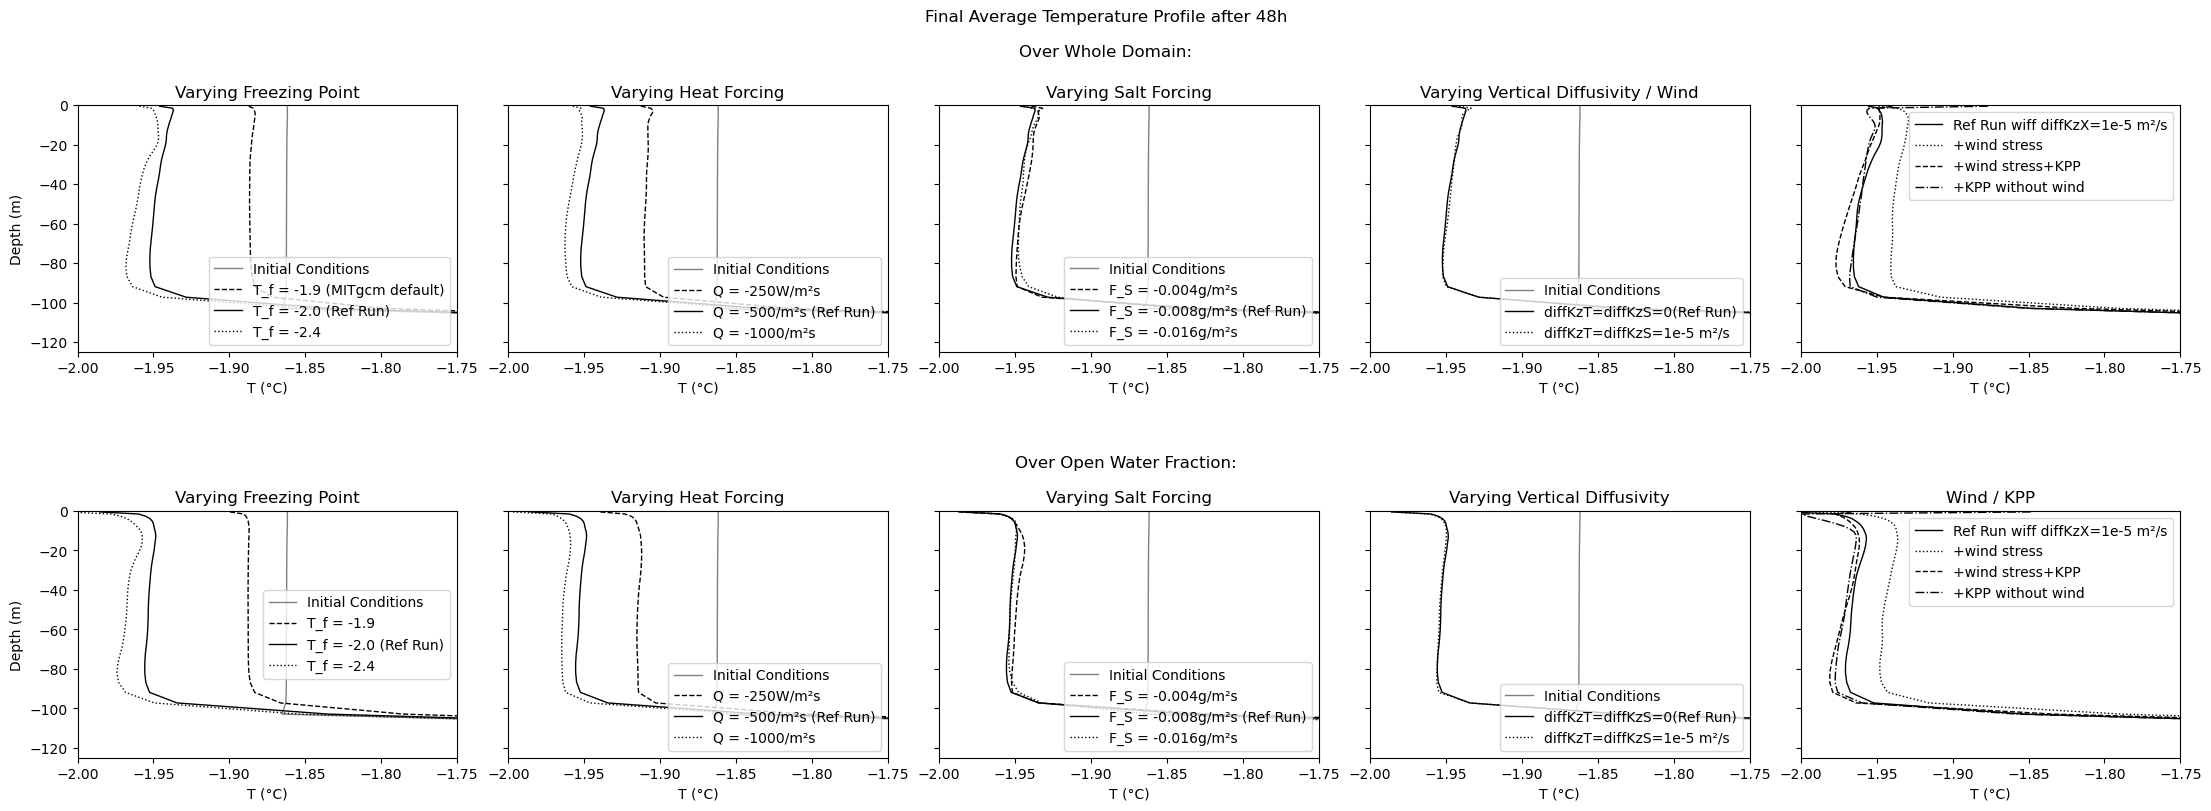

In [13]:
# both in one plot

fig, axs = plt.subplots(2,5, figsize = (22,8), sharex = False, sharey = True, constrained_layout = True)
plt.rcParams['lines.linewidth'] = 1

# WHOLE DOMAIN

# freezing point variations
axs[0,0].set_title("Varying Freezing Point")
axs[0,0].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,0].plot(final_avg_T_wholedomain.MIZ014, final_avg_T_wholedomain.index, label = "T_f = -1.9 (MITgcm default)", color = "black", linestyle = "dashed")
axs[0,0].plot(final_avg_T_wholedomain.MIZ009, final_avg_T_wholedomain.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[0,0].plot(final_avg_T_wholedomain.MIZ015, final_avg_T_wholedomain.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[0,0].set_ylabel("Depth (m)")

# heat flux variations
axs[0,1].set_title("Varying Heat Forcing")
axs[0,1].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,1].plot(final_avg_T_wholedomain.MIZ010, final_avg_T_wholedomain.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[0,1].plot(final_avg_T_wholedomain.MIZ009, final_avg_T_wholedomain.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[0,1].plot(final_avg_T_wholedomain.MIZ011, final_avg_T_wholedomain.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")

# salt forcing variation
axs[0,2].set_title("Varying Salt Forcing")
axs[0,2].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,2].plot(final_avg_T_wholedomain.MIZ012, final_avg_T_wholedomain.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[0,2].plot(final_avg_T_wholedomain.MIZ009, final_avg_T_wholedomain.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black")
axs[0,2].plot(final_avg_T_wholedomain.MIZ013, final_avg_T_wholedomain.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")

# diffKz/wind variation
axs[0,3].set_title("Varying Vertical Diffusivity / Wind")
axs[0,3].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,3].plot(final_avg_T_wholedomain.MIZ009, final_avg_T_wholedomain.index, label = "diffKzT=diffKzS=0(Ref Run)", color = "black")
axs[0,3].plot(final_avg_T_wholedomain.MIZ017, final_avg_T_wholedomain.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = "black", linestyle = "dotted")

# wind & KPP
axs[0,4].plot(final_avg_T_wholedomain.MIZ016, final_avg_T_wholedomain.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = "black")
axs[0,4].plot(final_avg_T_wholedomain.MIZ018, final_avg_T_wholedomain.index, label = "+wind stress", color = "black", linestyle = "dotted")
axs[0,4].plot(final_avg_T_wholedomain.MIZ019, final_avg_T_wholedomain.index, label = "+wind stress+KPP", color = "black", linestyle = "dashed")
axs[0,4].plot(final_avg_T_wholedomain.MIZ020, final_avg_T_wholedomain.index, label = "+KPP without wind", color = "black", linestyle = "dashdot")

# OPEN WATER FRACTION
# freezing point variations
axs[1,0].set_title("Varying Freezing Point")
axs[1,0].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,0].plot(final_avg_T_openwater.MIZ014, final_avg_T_openwater.index, label = "T_f = -1.9", color = "black", linestyle = "dashed")
axs[1,0].plot(final_avg_T_openwater.MIZ009, final_avg_T_openwater.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[1,0].plot(final_avg_T_openwater.MIZ015, final_avg_T_openwater.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[1,0].set_ylabel("Depth (m)")


# heat flux variations
axs[1,1].set_title("Varying Heat Forcing")
axs[1,1].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,1].plot(final_avg_T_openwater.MIZ010, final_avg_T_openwater.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[1,1].plot(final_avg_T_openwater.MIZ009, final_avg_T_openwater.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[1,1].plot(final_avg_T_openwater.MIZ011, final_avg_T_openwater.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")


# salt forcing variation
axs[1,2].set_title("\n\n\nOver Open Water Fraction: \n\nVarying Salt Forcing")
axs[1,2].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,2].plot(final_avg_T_openwater.MIZ012, final_avg_T_openwater.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[1,2].plot(final_avg_T_openwater.MIZ009, final_avg_T_openwater.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black", linewidth = 1)
axs[1,2].plot(final_avg_T_openwater.MIZ013, final_avg_T_openwater.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")

# diffKz variation
axs[1,3].set_title("Varying Vertical Diffusivity")
axs[1,3].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,3].plot(final_avg_T_openwater.MIZ009, final_avg_T_openwater.index, label = "diffKzT=diffKzS=0(Ref Run)", color = "black")
axs[1,3].plot(final_avg_T_openwater.MIZ017, final_avg_T_openwater.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = "black", linestyle = "dotted")

# wind & KPP
axs[1,4].set_title("Wind / KPP")
axs[1,4].plot(final_avg_T_openwater.MIZ016, final_avg_T_openwater.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = "black")
axs[1,4].plot(final_avg_T_openwater.MIZ018, final_avg_T_openwater.index, label = "+wind stress", color = "black", linestyle = "dotted")
axs[1,4].plot(final_avg_T_openwater.MIZ019, final_avg_T_openwater.index, label = "+wind stress+KPP", color = "black", linestyle = "dashed")
axs[1,4].plot(final_avg_T_openwater.MIZ020, final_avg_T_openwater.index, label = "+KPP without wind", color = "black", linestyle = "dashdot")


for ax in axs.flatten():
    ax.legend()
    ax.set_ylim(-125,0)
    ax.set_xlim(-2,-1.75)
    ax.set_xlabel("T (°C)")
    

plt.suptitle("Final Average Temperature Profile after 48h\n\nOver Whole Domain:\n")


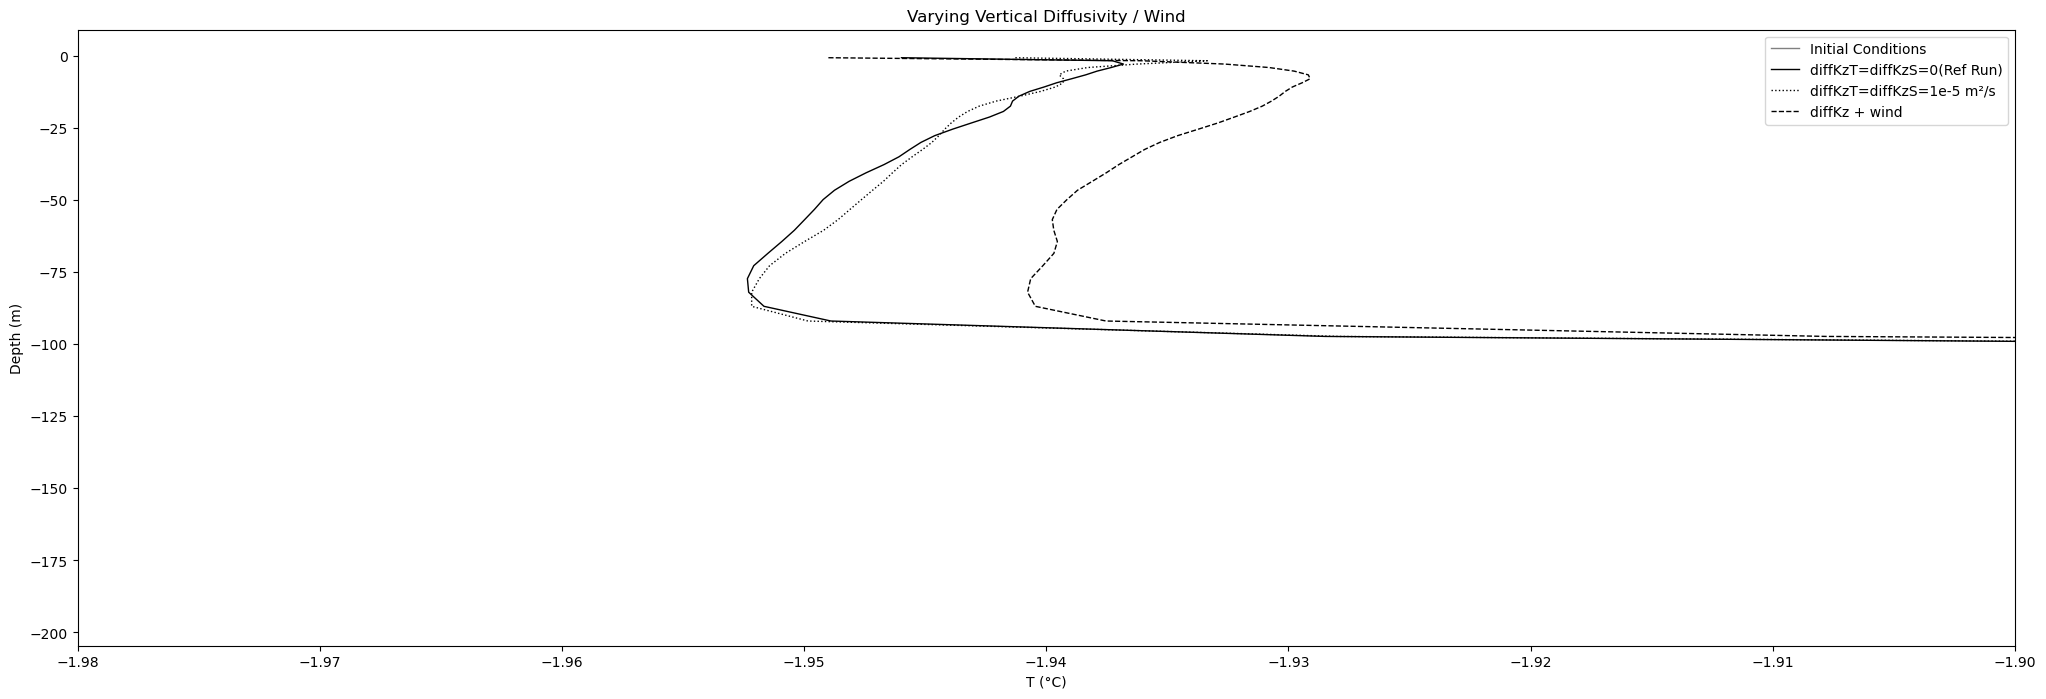

In [19]:
# close look at some diffk + wind varations
fig, axs = plt.subplots(figsize = (25,8))
plt.rcParams['lines.linewidth'] = 1

axs.set_title("Varying Vertical Diffusivity / Wind")
axs.plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs.plot(final_avg_T_wholedomain.MIZ009, final_avg_T_wholedomain.index, label = "diffKzT=diffKzS=0(Ref Run)", color = "black")
axs.plot(final_avg_T_wholedomain.MIZ017, final_avg_T_wholedomain.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = "black", linestyle = "dotted")
axs.plot(final_avg_T_wholedomain.MIZ018, final_avg_T_wholedomain.index, label = "diffKz + wind", color = "black", linestyle = "dashed")
axs.set_xlabel("T (°C)")
axs.set_ylabel("Depth (m)")
axs.set_xlim(-1.98,-1.9)

axs.legend()

## Plot Average Salinity Profiles

Text(0.5, 0.98, 'Final Average Salinity Profile after 48h\n\nOver Whole Domain:\n')

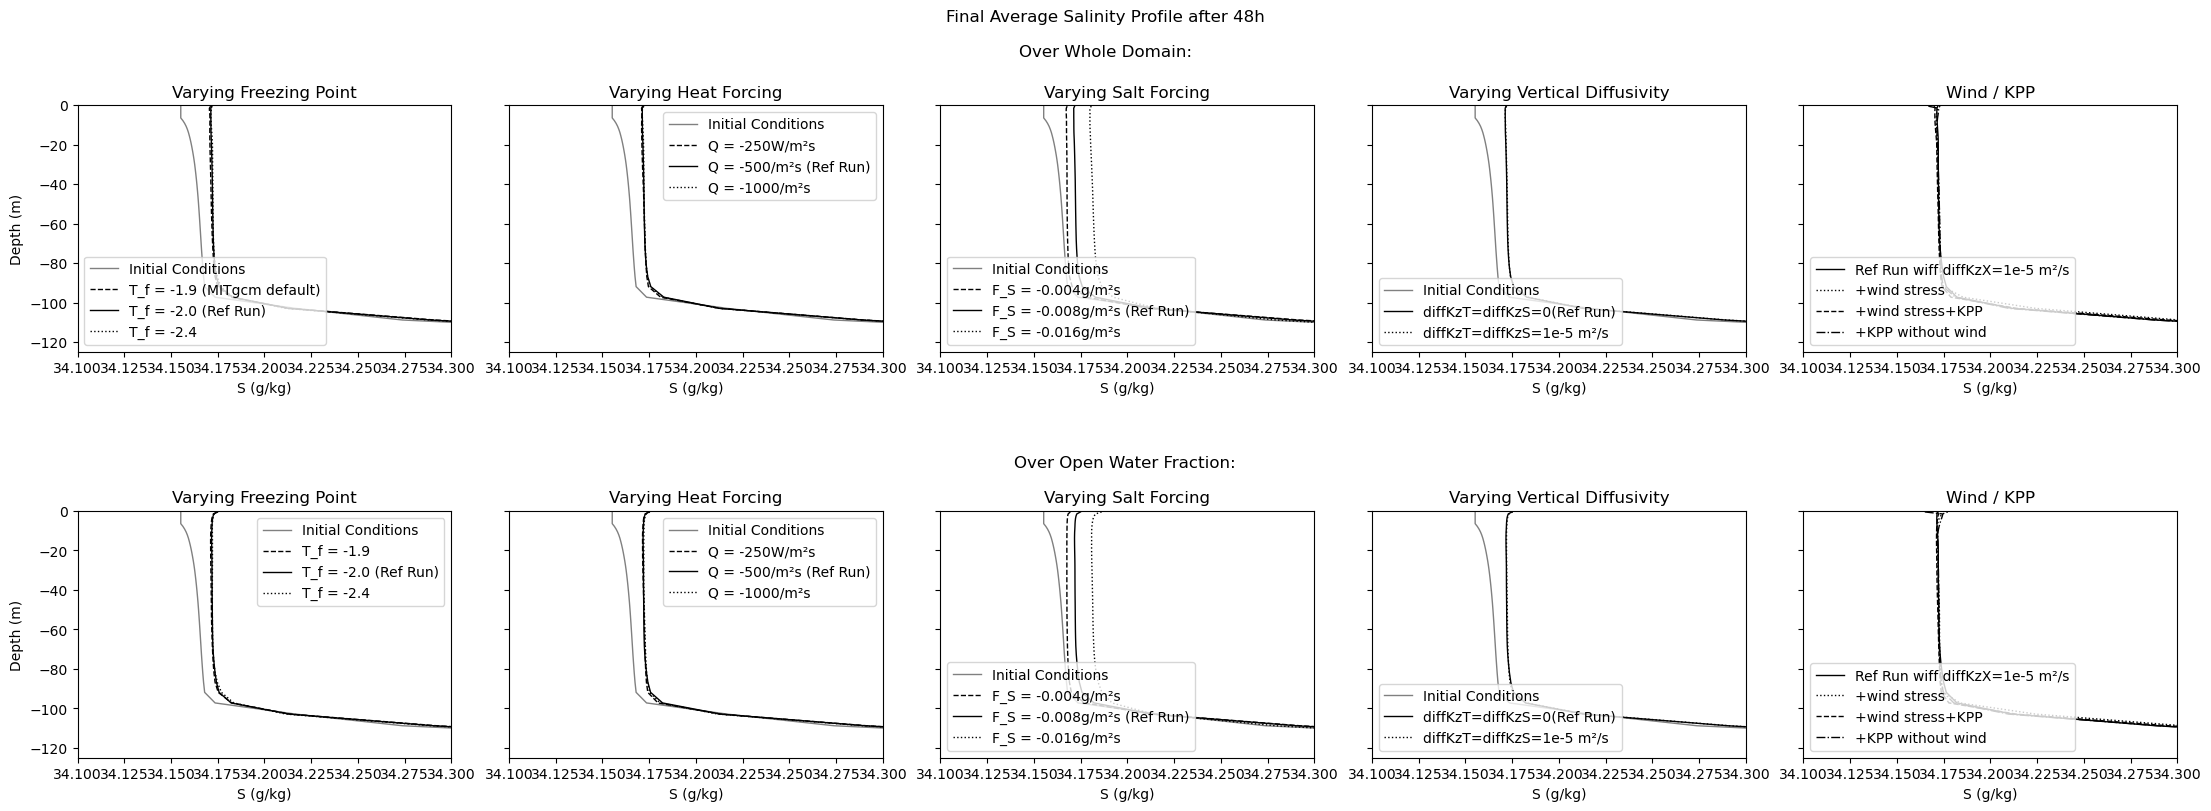

In [14]:
# both in one plot

fig, axs = plt.subplots(2,5, figsize = (22,8), sharex = False, sharey = True, constrained_layout = True)
plt.rcParams['lines.linewidth'] = 1

# WHOLE DOMAIN

# freezing point variations
axs[0,0].set_title("Varying Freezing Point")
axs[0,0].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,0].plot(final_avg_S_wholedomain.MIZ014, final_avg_S_wholedomain.index, label = "T_f = -1.9 (MITgcm default)", color = "black", linestyle = "dashed")
axs[0,0].plot(final_avg_S_wholedomain.MIZ009, final_avg_S_wholedomain.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[0,0].plot(final_avg_S_wholedomain.MIZ015, final_avg_S_wholedomain.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[0,0].set_ylabel("Depth (m)")

# heat flux variations
axs[0,1].set_title("Varying Heat Forcing")
axs[0,1].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,1].plot(final_avg_S_wholedomain.MIZ010, final_avg_S_wholedomain.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[0,1].plot(final_avg_S_wholedomain.MIZ009, final_avg_S_wholedomain.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[0,1].plot(final_avg_S_wholedomain.MIZ011, final_avg_S_wholedomain.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")

# salt forcing variation
axs[0,2].set_title("Varying Salt Forcing")
axs[0,2].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,2].plot(final_avg_S_wholedomain.MIZ012, final_avg_S_wholedomain.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[0,2].plot(final_avg_S_wholedomain.MIZ009, final_avg_S_wholedomain.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black")
axs[0,2].plot(final_avg_S_wholedomain.MIZ013, final_avg_S_wholedomain.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")

# diffKz variation
axs[0,3].set_title("Varying Vertical Diffusivity")
axs[0,3].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,3].plot(final_avg_S_wholedomain.MIZ009, final_avg_S_wholedomain.index, label = "diffKzT=diffKzS=0(Ref Run)", color = "black")
axs[0,3].plot(final_avg_S_wholedomain.MIZ017, final_avg_S_wholedomain.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = "black", linestyle = "dotted")

# wind & KPP
axs[0,4].set_title("Wind / KPP")
axs[0,4].plot(final_avg_S_wholedomain.MIZ016, final_avg_S_wholedomain.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = "black")
axs[0,4].plot(final_avg_S_wholedomain.MIZ018, final_avg_S_wholedomain.index, label = "+wind stress", color = "black", linestyle = "dotted")
axs[0,4].plot(final_avg_S_wholedomain.MIZ019, final_avg_S_wholedomain.index, label = "+wind stress+KPP", color = "black", linestyle = "dashed")
axs[0,4].plot(final_avg_S_wholedomain.MIZ020, final_avg_S_wholedomain.index, label = "+KPP without wind", color = "black", linestyle = "dashdot")

# OPEN WATER FRACTION
# freezing point variations
axs[1,0].set_title("Varying Freezing Point")
axs[1,0].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,0].plot(final_avg_S_openwater.MIZ014, final_avg_S_openwater.index, label = "T_f = -1.9", color = "black", linestyle = "dashed")
axs[1,0].plot(final_avg_S_openwater.MIZ009, final_avg_S_openwater.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[1,0].plot(final_avg_S_openwater.MIZ015, final_avg_S_openwater.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[1,0].set_ylabel("Depth (m)")
axs[1,0].set_xlabel("S (g/kg)")


# heat flux variations
axs[1,1].set_title("Varying Heat Forcing")
axs[1,1].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,1].plot(final_avg_S_openwater.MIZ010, final_avg_S_openwater.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[1,1].plot(final_avg_S_openwater.MIZ009, final_avg_S_openwater.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[1,1].plot(final_avg_S_openwater.MIZ011, final_avg_S_openwater.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")
axs[1,1].set_xlabel("S (g/kg)")


# salt forcing variation
axs[1,2].set_title("\n\n\nOver Open Water Fraction: \n\nVarying Salt Forcing")
axs[1,2].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,2].plot(final_avg_S_openwater.MIZ012, final_avg_S_openwater.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[1,2].plot(final_avg_S_openwater.MIZ009, final_avg_S_openwater.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black", linewidth = 1)
axs[1,2].plot(final_avg_S_openwater.MIZ013, final_avg_S_openwater.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")
axs[1,2].set_xlabel("S (g/kg)")

# diffKz variation
axs[1,3].set_title("Varying Vertical Diffusivity")
axs[1,3].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,3].plot(final_avg_S_openwater.MIZ009, final_avg_S_openwater.index, label = "diffKzT=diffKzS=0(Ref Run)", color = "black")
axs[1,3].plot(final_avg_S_openwater.MIZ017, final_avg_S_openwater.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = "black", linestyle = "dotted")

# wind & KPP
axs[1,4].set_title("Wind / KPP")
axs[1,4].plot(final_avg_S_wholedomain.MIZ016, final_avg_S_wholedomain.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = "black")
axs[1,4].plot(final_avg_S_openwater.MIZ018, final_avg_S_openwater.index, label = "+wind stress", color = "black", linestyle = "dotted")
axs[1,4].plot(final_avg_S_openwater.MIZ019, final_avg_S_openwater.index, label = "+wind stress+KPP", color = "black", linestyle = "dashed")
axs[1,4].plot(final_avg_S_openwater.MIZ020, final_avg_S_openwater.index, label = "+KPP without wind", color = "black", linestyle = "dashdot")

for ax in axs.flatten():
    ax.legend()
    ax.set_ylim(-125,0)
    ax.set_xlim(34.1,34.3)
    ax.set_xlabel("S (g/kg)")
    

plt.suptitle("Final Average Salinity Profile after 48h\n\nOver Whole Domain:\n")


##  Plot N²

$$ N^2 = -\frac{g}{\rho}\frac{\Delta \rho}{\Delta z}$$

$N^2>0$ stable\
$N^2<0$ instable

Text(0.5, 0.98, 'Final Average N² Profile after 48h\n\nOver Whole Domain:\n')

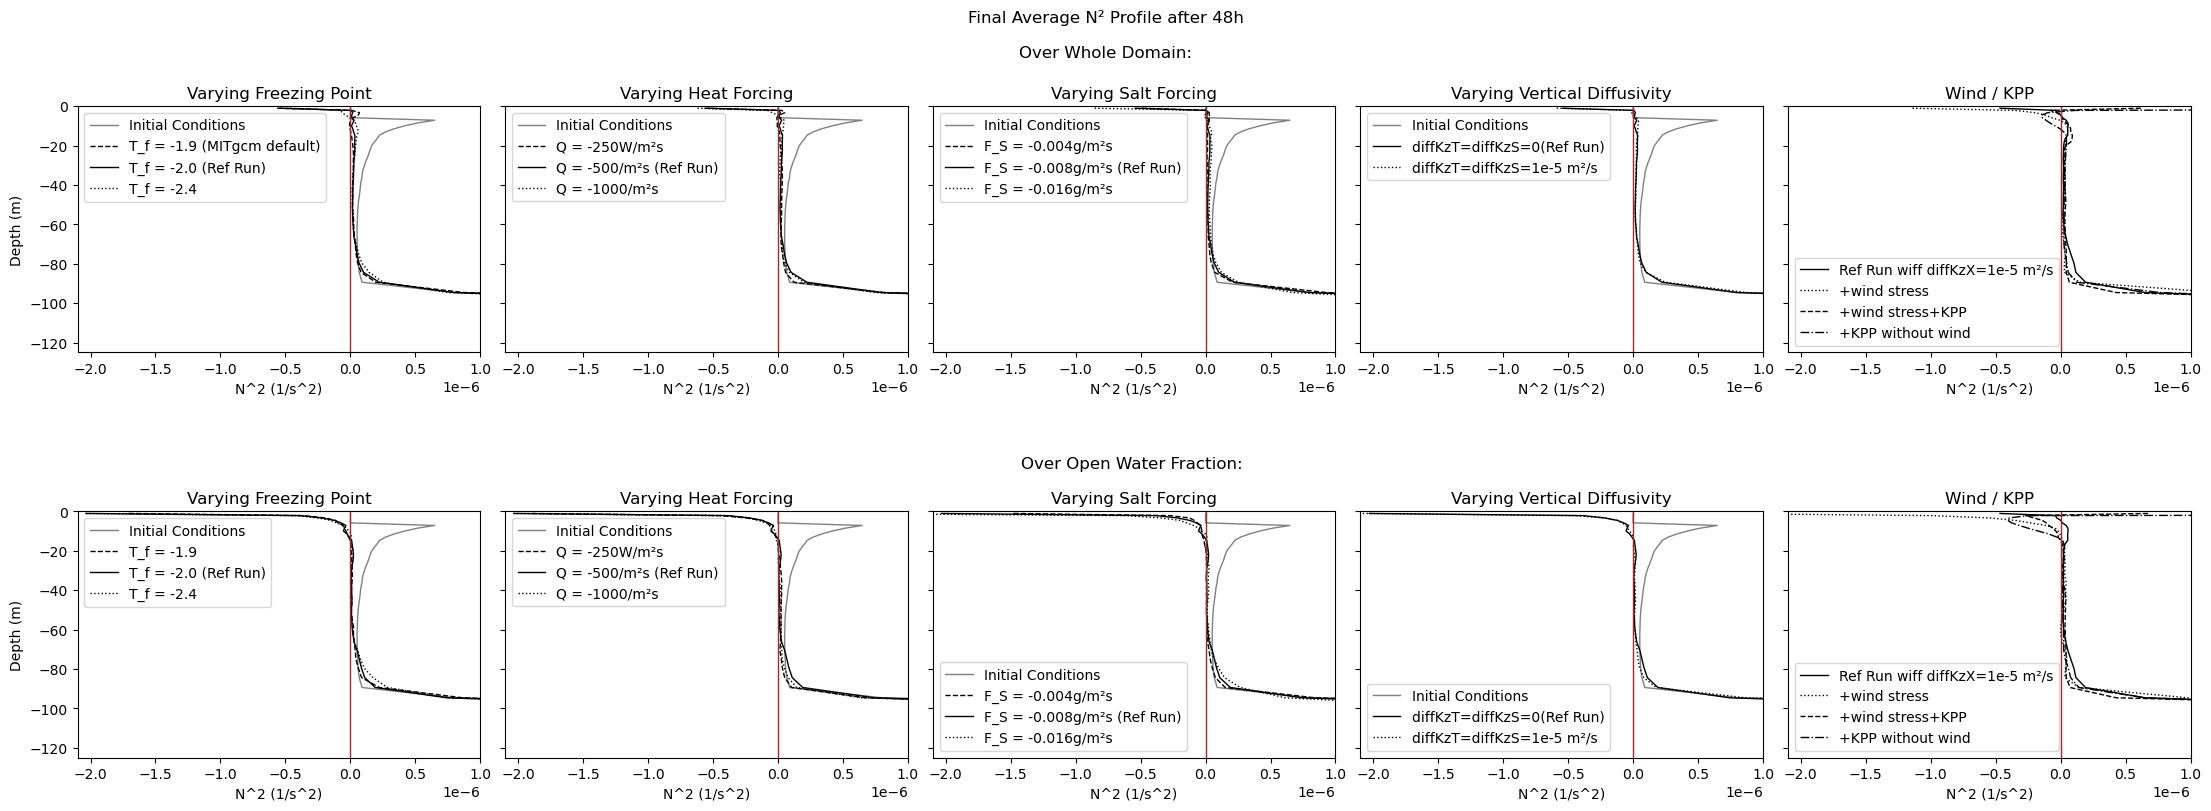

In [15]:
# both in one plot

fig, axs = plt.subplots(2,5, figsize = (22,8), sharex = False, sharey = True, constrained_layout = True)
plt.rcParams['lines.linewidth'] = 1

# WHOLE DOMAIN

# freezing point variations
axs[0,0].set_title("Varying Freezing Point")
axs[0,0].plot(final_avg_N2_wholedomain.initCond, final_avg_N2_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,0].plot(final_avg_N2_wholedomain.MIZ014, final_avg_N2_wholedomain.index, label = "T_f = -1.9 (MITgcm default)", color = "black", linestyle = "dashed")
axs[0,0].plot(final_avg_N2_wholedomain.MIZ009, final_avg_N2_wholedomain.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[0,0].plot(final_avg_N2_wholedomain.MIZ015, final_avg_N2_wholedomain.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[0,0].set_ylabel("Depth (m)")

# heat flux variations
axs[0,1].set_title("Varying Heat Forcing")
axs[0,1].plot(final_avg_N2_wholedomain.initCond, final_avg_N2_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,1].plot(final_avg_N2_wholedomain.MIZ010, final_avg_N2_wholedomain.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[0,1].plot(final_avg_N2_wholedomain.MIZ009, final_avg_N2_wholedomain.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[0,1].plot(final_avg_N2_wholedomain.MIZ011, final_avg_N2_wholedomain.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")

# salt forcing variation
axs[0,2].set_title("Varying Salt Forcing")
axs[0,2].plot(final_avg_N2_wholedomain.initCond, final_avg_N2_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,2].plot(final_avg_N2_wholedomain.MIZ012, final_avg_N2_wholedomain.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[0,2].plot(final_avg_N2_wholedomain.MIZ009, final_avg_N2_wholedomain.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black")
axs[0,2].plot(final_avg_N2_wholedomain.MIZ013, final_avg_N2_wholedomain.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")

# diffKz variation
axs[0,3].set_title("Varying Vertical Diffusivity")
axs[0,3].plot(final_avg_N2_wholedomain.initCond, final_avg_N2_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,3].plot(final_avg_N2_wholedomain.MIZ009, final_avg_N2_wholedomain.index, label = "diffKzT=diffKzS=0(Ref Run)", color = "black")
axs[0,3].plot(final_avg_N2_wholedomain.MIZ017, final_avg_N2_wholedomain.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = "black", linestyle = "dotted")

# wind & KPP
axs[0,4].set_title("Wind / KPP")
axs[0,4].plot(final_avg_N2_wholedomain.MIZ016, final_avg_N2_wholedomain.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = "black")
axs[0,4].plot(final_avg_N2_wholedomain.MIZ018, final_avg_N2_wholedomain.index, label = "+wind stress", color = "black", linestyle = "dotted")
axs[0,4].plot(final_avg_N2_wholedomain.MIZ019, final_avg_N2_wholedomain.index, label = "+wind stress+KPP", color = "black", linestyle = "dashed")
axs[0,4].plot(final_avg_N2_wholedomain.MIZ020, final_avg_N2_wholedomain.index, label = "+KPP without wind", color = "black", linestyle = "dashdot")

# OPEN WATER FRACTION
# freezing point variations
axs[1,0].set_title("Varying Freezing Point")
axs[1,0].plot(final_avg_N2_wholedomain.initCond, final_avg_N2_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,0].plot(final_avg_N2_openwater.MIZ014, final_avg_N2_openwater.index, label = "T_f = -1.9", color = "black", linestyle = "dashed")
axs[1,0].plot(final_avg_N2_openwater.MIZ009, final_avg_N2_openwater.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[1,0].plot(final_avg_N2_openwater.MIZ015, final_avg_N2_openwater.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[1,0].set_ylabel("Depth (m)")
axs[1,0].set_xlabel("N^2 (1/s^2)")


# heat flux variations
axs[1,1].set_title("Varying Heat Forcing")
axs[1,1].plot(final_avg_N2_wholedomain.initCond, final_avg_N2_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,1].plot(final_avg_N2_openwater.MIZ010, final_avg_N2_openwater.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[1,1].plot(final_avg_N2_openwater.MIZ009, final_avg_N2_openwater.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[1,1].plot(final_avg_N2_openwater.MIZ011, final_avg_N2_openwater.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")
axs[1,1].set_xlabel("N^2 (1/s^2)")


# salt forcing variation
axs[1,2].set_title("\n\n\nOver Open Water Fraction: \n\nVarying Salt Forcing")
axs[1,2].plot(final_avg_N2_wholedomain.initCond, final_avg_N2_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,2].plot(final_avg_N2_openwater.MIZ012, final_avg_N2_openwater.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[1,2].plot(final_avg_N2_openwater.MIZ009, final_avg_N2_openwater.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black", linewidth = 1)
axs[1,2].plot(final_avg_N2_openwater.MIZ013, final_avg_N2_openwater.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")
axs[1,2].set_xlabel("N^2 (1/s^2)")

# diffKz variation
axs[1,3].set_title("Varying Vertical Diffusivity")
axs[1,3].plot(final_avg_N2_wholedomain.initCond, final_avg_N2_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,3].plot(final_avg_N2_openwater.MIZ009, final_avg_N2_openwater.index, label = "diffKzT=diffKzS=0(Ref Run)", color = "black")
axs[1,3].plot(final_avg_N2_openwater.MIZ017, final_avg_N2_openwater.index, label = "diffKzT=diffKzS=1e-5 m²/s", color = "black", linestyle = "dotted")

# wind & KPP
axs[1,4].set_title("Wind / KPP")
axs[1,4].plot(final_avg_N2_wholedomain.MIZ016, final_avg_N2_wholedomain.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = "black")
axs[1,4].plot(final_avg_N2_openwater.MIZ018, final_avg_N2_openwater.index, label = "+wind stress", color = "black", linestyle = "dotted")
axs[1,4].plot(final_avg_N2_openwater.MIZ019, final_avg_N2_openwater.index, label = "+wind stress+KPP", color = "black", linestyle = "dashed")
axs[1,4].plot(final_avg_N2_openwater.MIZ020, final_avg_N2_openwater.index, label = "+KPP without wind", color = "black", linestyle = "dashdot")

axs[1,3].set_xlabel("N^2 (1/s^2)")

for ax in axs.flatten():
    ax.vlines(0, -200,0, color = "brown")
    ax.legend()
    ax.set_ylim(-125,0)
    ax.set_xlim(-0.21e-5,0.1e-5) # zoom
    # ax.set_xlim(-0.25e-5,1.3e-5)
    ax.set_xlabel("N^2 (1/s^2)")
    

plt.suptitle("Final Average N² Profile after 48h\n\nOver Whole Domain:\n")


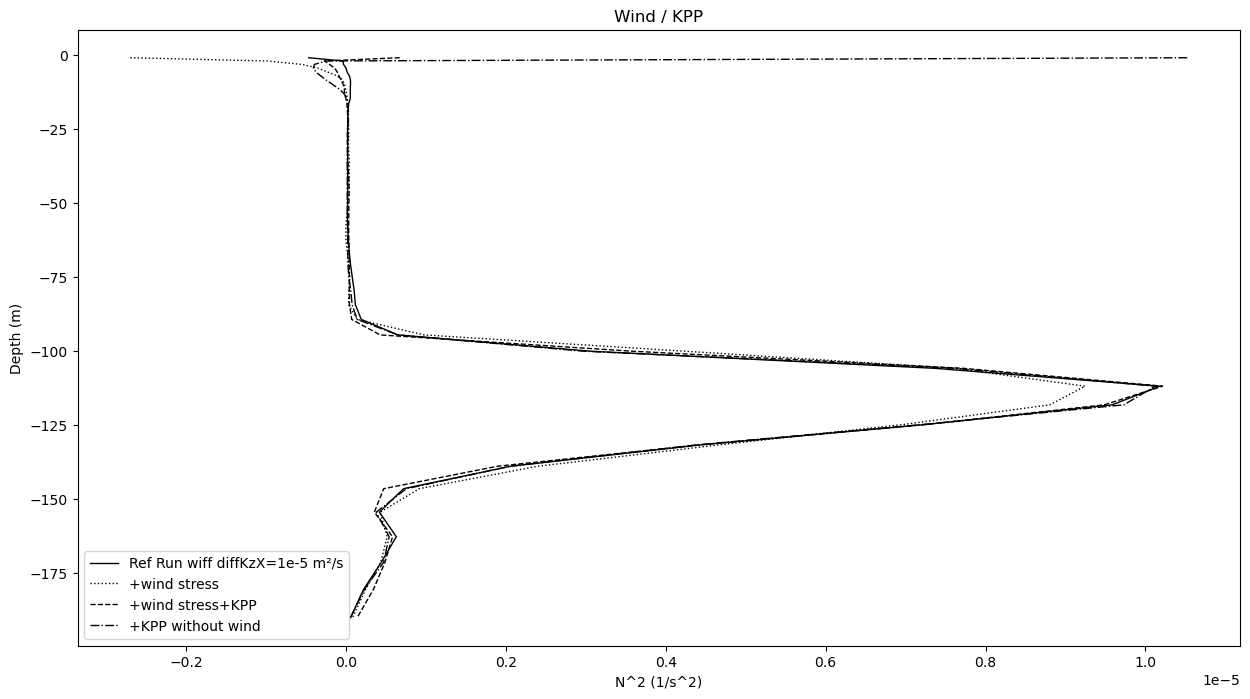

In [19]:
# close look at wind & kpp variation

fig, ax = plt.subplots(figsize = (15,8))

# wind & KPP
ax.set_title("Wind / KPP")
ax.plot(final_avg_N2_wholedomain.MIZ016, final_avg_N2_wholedomain.index, label = "Ref Run wiff diffKzX=1e-5 m²/s", color = "black")
ax.plot(final_avg_N2_openwater.MIZ018, final_avg_N2_openwater.index, label = "+wind stress", color = "black", linestyle = "dotted")
ax.plot(final_avg_N2_openwater.MIZ019, final_avg_N2_openwater.index, label = "+wind stress+KPP", color = "black", linestyle = "dashed")
ax.plot(final_avg_N2_openwater.MIZ020, final_avg_N2_openwater.index, label = "+KPP without wind", color = "black", linestyle = "dashdot")
ax.set_xlabel("N^2 (1/s^2)")
ax.set_ylabel("Depth (m)")
ax.legend()